#installs

In [1]:
!pip install gpflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 392.9/392.9 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 7.1 MB/s eta 0:00:00


# GPLVM

In [1]:
!pip install gpflow==2.5.1

In [25]:
import numpy as np
import gpflow
import matplotlib.pyplot as plt
from gpflow.utilities import print_summary

# 1. Configuración inicial
gpflow.config.set_default_float(np.float64)

# 2. Cargar y preprocesar datos
data = np.load('three_phase_oil_flow.npz')
Y = data['Y'].astype(np.float64)
labels = data['labels']

# 3. Inicialización con PCA
latent_dim = 2
X_pca = gpflow.utilities.ops.pca_reduce(Y, latent_dim).numpy()

# 4. Definir modelo GPLVM básico
kernel = gpflow.kernels.SquaredExponential(lengthscales=[1.0]*latent_dim)

# 4. Definir modelo GPLVM (versión corregida)
model = gpflow.models.GPLVM(
    data=Y,
    X_data_mean=X_pca,
    kernel=kernel,
    latent_dim=latent_dim  # Parámetro requerido añadido
)

# 5. Configurar parámetros entrenables
# gpflow.set_trainable(model.X_data, True)
gpflow.set_trainable(model.kernel.lengthscales, True)
gpflow.set_trainable(model.kernel.variance, True)
gpflow.set_trainable(model.likelihood.variance, True)

# 6. Entrenamiento
optimizer = gpflow.optimizers.Scipy()
optimizer.minimize(
    model.training_loss,
    variables=model.trainable_variables,
    method='l-bfgs-b',
    options={'maxiter': 1000}
)

print_summary(model)

╒═══════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤══════════╤═════════╤═══════════════════════════════╕
│ name                      │ class     │ transform        │ prior   │ trainable   │ shape    │ dtype   │ value                         │
╞═══════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪══════════╪═════════╪═══════════════════════════════╡
│ GPLVM.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()       │ float64 │ 0.6817412519232013            │
├───────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼──────────┼─────────┼───────────────────────────────┤
│ GPLVM.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ (2,)     │ float64 │ [0.40549504 1.87977605]       │
├───────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼──────────┼─────────┼───────────────────────────────┤
│ GPLVM.likelihood.variance │ Para

In [10]:
# model.predict_f_samples(X_pca)
# model.predict_y(X_pca)
# model.predict_f(X_pca)

<tf.Tensor: shape=(100, 12), dtype=float64, numpy=
array([[ 1.03868175e+00, -8.50037619e-03,  1.04317611e+00, ...,
         3.09058404e-02,  1.06035186e+00,  1.59012836e-01],
       [ 7.58664238e-01,  3.72282372e-01,  3.22749110e-01, ...,
         7.96146552e-01,  2.84912419e-01,  1.28670806e+00],
       [ 5.69308979e-01,  3.44777976e-01,  8.36247683e-01, ...,
         7.71231524e-01,  8.76861648e-01,  6.59952683e-01],
       ...,
       [-2.26577845e-02,  1.19865399e+00, -1.61535752e-01, ...,
         2.50104391e+00, -1.26306301e-01,  1.09822638e+00],
       [ 4.77019303e-01,  4.96161809e-01,  7.27162669e-01, ...,
         1.10055376e+00,  7.61154726e-01,  9.32471427e-01],
       [-1.37478863e-01,  9.80471232e-01,  4.25437420e-04, ...,
         1.49343653e+00, -2.72529212e-01,  9.00352790e-01]])>

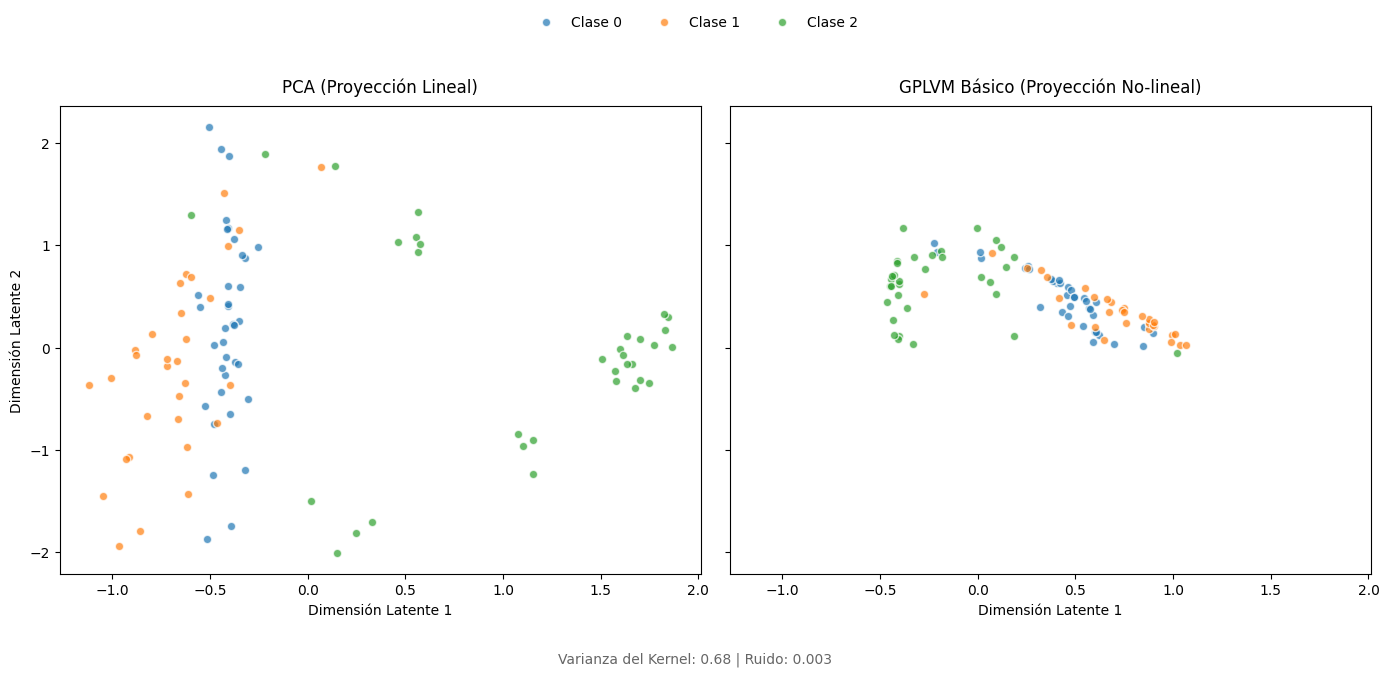

name,class,transform,prior,trainable,shape,dtype,value
GPLVM.kernel.variance,Parameter,Softplus,,True,(),float64,0.6817412519232013
GPLVM.kernel.lengthscales,Parameter,Softplus,,True,"(2,)",float64,[0.40549504 1.87977605]
GPLVM.likelihood.variance,Parameter,Softplus + Shift,,True,(),float64,0.002776249810384317
GPLVM.data[0],Parameter,Identity,,True,"(100, 2)",float64,"[[-1.83304699, -1.73957045..."


In [26]:
# 7. Visualización comparativa con PCA
GPLVM_X = model.predict_y(X_pca)[0].numpy()  # Acceder a las variables latentes

fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Plot PCA
for i in np.unique(labels):
    mask = labels == i
    ax[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                 label=f'Clase {i}', alpha=0.7, edgecolor='w')

# Plot GPLVM
for i in np.unique(labels):
    mask = labels == i
    ax[1].scatter(GPLVM_X[mask, 0], GPLVM_X[mask, 1],
                 label=f'Clase {i}', alpha=0.7, edgecolor='w')

# Configuración de los ejes
ax[0].set_title('PCA (Proyección Lineal)', fontsize=12, pad=10)
ax[1].set_title('GPLVM Básico (Proyección No-lineal)', fontsize=12, pad=10)
ax[0].set_ylabel('Dimensión Latente 2', fontsize=10)
ax[0].set_xlabel('Dimensión Latente 1', fontsize=10)
ax[1].set_xlabel('Dimensión Latente 1', fontsize=10)

# Leyenda unificada
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='upper center',
           ncol=3,
           bbox_to_anchor=(0.5, 1.05),
           frameon=False)

# Añadir información del modelo
plt.figtext(0.5, -0.05,
            f'Varianza del Kernel: {model.kernel.variance.numpy():.2f} | Ruido: {model.likelihood.variance.numpy():.3f}',
            ha='center', fontsize=10, color='#666666')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# 8. Resumen del modelo
print_summary(model, fmt='notebook')

# Bayesian-GPLVM  (three_phase_oil_flow dataset)

Unsupervised learning method, usually used for dimensionality reduction

apply on three_phase_oil_flow dataset

In [96]:
import gpflow
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [97]:
import urllib.request
url = 'https://github.com/spectraldani/UnscentedGPLVM/raw/master/data/three_phase_oil_flow.npz'  # Replace with the actual URL
urllib.request.urlretrieve(url, 'three_phase_oil_flow.npz')  # Save as 'three_phase_oil_flow.npz'

('three_phase_oil_flow.npz', <http.client.HTTPMessage at 0x7d8e10205050>)

In [98]:
data = np.load('/content/three_phase_oil_flow.npz')
Y = data['Y'].astype(np.float64)  # following the GPflow notation we assume this dataset has size [num_data, output_dim]
labels = data['labels']  # integer in [0, 2] indicating to which class the datapoint belongs [num_data,]. Not used for model fitting, only for plotting afterwards.

print('Number of points: {} and Number of dimensions: {}'.format(Y.shape[0], Y.shape[1]))
print(f'Datos Originales: {Y.shape}')
print(f'Etiquetas: {labels}')

Number of points: 100 and Number of dimensions: 12
Datos Originales: (100, 12)
Etiquetas: [2 1 0 1 0 1 0 0 1 0 1 0 1 0 0 2 2 2 2 0 1 0 0 2 2 0 1 2 1 2 1 2 2 0 0 1 1
 1 1 1 2 1 0 1 0 0 0 2 2 1 1 0 2 0 0 0 2 2 1 0 1 0 0 2 2 0 2 0 1 2 1 1 0 0
 1 1 0 2 2 1 1 0 0 1 1 2 2 1 2 0 2 2 0 2 2 2 0 2 0 2]


Model Construction

In [99]:
# 1. Configuración inicial
gpflow.config.set_default_float(np.float64)

# 2. Cargar datos (previamente descargados)
data = np.load('three_phase_oil_flow.npz')
Y = data['Y'].astype(np.float64)
labels = data['labels']

# 3. Inicialización del espacio latente
latent_dim = 2 # dimensiones latentes
X_mean_init = gpflow.utilities.ops.pca_reduce(Y, latent_dim)  # Inicializar via pca

# 4. Configurar varianza inicial para X_data
X_data_var_init = np.ones_like(X_mean_init) * 0.01  # Pequeña varianza inicial
num_inducing = 20 # number of inducing pts
Z_inducing_inputs_init = np.random.permutation(X_mean_init)[:num_inducing]  # Pick inducing inputs randomly from dataset initialisation


In [100]:
#5 kernel RBF
kernel = gpflow.kernels.SquaredExponential(lengthscales=[1.0] * latent_dim)

In [101]:
# 6. Crear modelo BayesianGPLVM con parámetros correctos
#puede usar # puntos inducidos ó varible con ptos inducido

model = gpflow.models.BayesianGPLVM(
    data=Y,  # Debe ser una tupla
    X_data_mean=X_mean_init,
    X_data_var=X_data_var_init,
    kernel=kernel,
    # inducing_variable=Z_inducing_inputs_init,
    num_inducing_variables=30
)


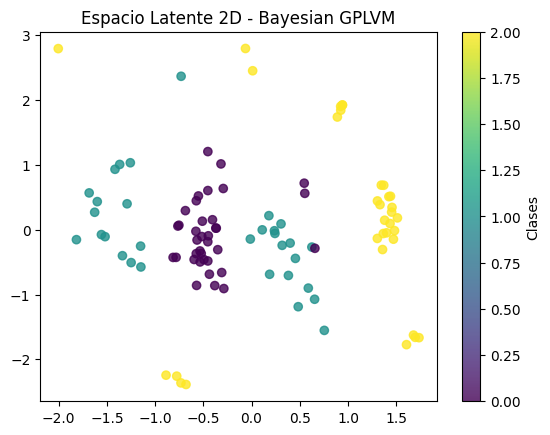

In [102]:
# 7. Entrenamiento
optimizer = gpflow.optimizers.Scipy()
optimizer.minimize(
    model.training_loss,
    variables=model.trainable_variables,
    method='l-bfgs-b',
    options={'maxiter': 1000}
)

# 8. Visualización
X_latent = model.X_data_mean.numpy()
plt.scatter(X_latent[:, 0], X_latent[:, 1], c=labels, cmap='viridis', alpha=0.8)
plt.colorbar(label='Clases')
plt.title('Espacio Latente 2D - Bayesian GPLVM')
plt.show()

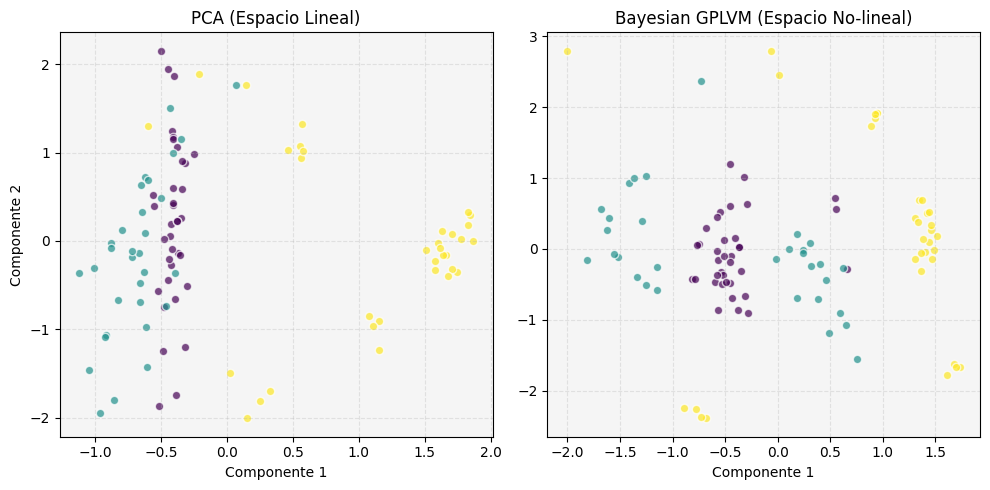

In [103]:
import matplotlib.pyplot as plt
import numpy as np

# Datos para los gráficos (reemplázalos con tus datos reales)
XPCAplot = gpflow.utilities.ops.pca_reduce(Y, 2).numpy()  # Datos para PCA
GPLVM_X_mean = model.X_data_mean.numpy()  # Datos para GPLVM Latente
labels = data['labels']  # Etiquetas de los datos

# Crear figura con dos subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Subplot 1: PCA
cmap = plt.cm.viridis
unique_labels = np.unique(labels)
colors = cmap(np.linspace(0, 1, len(unique_labels)))
for i, label in enumerate(unique_labels):
    mask = labels == label
    ax1.scatter(XPCAplot[mask, 0], XPCAplot[mask, 1], color=colors[i], alpha=0.7, edgecolor='w', label=f'Clase {label}')
ax1.set_title('PCA (Espacio Lineal)')
ax1.set_xlabel('Componente 1')
ax1.set_ylabel('Componente 2')
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.set_facecolor('#f5f5f5')

# Subplot 2: GPLVM
for i, label in enumerate(unique_labels):
    mask = labels == label
    ax2.scatter(GPLVM_X_mean[mask, 0], GPLVM_X_mean[mask, 1], color=colors[i], alpha=0.7, edgecolor='w', label=f'Clase {label}')
ax2.set_title('Bayesian GPLVM (Espacio No-lineal)')
ax2.set_xlabel('Componente 1')
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.set_facecolor('#f5f5f5')

# Ajustes adicionales
plt.tight_layout()
plt.show()

In [104]:
print_summary(model)

╒═══════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤══════════╤═════════╤══════════════════════════════════════╕
│ name                              │ class     │ transform        │ prior   │ trainable   │ shape    │ dtype   │ value                                │
╞═══════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪══════════╪═════════╪══════════════════════════════════════╡
│ BayesianGPLVM.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()       │ float64 │ 0.5722150225683782                   │
├───────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼──────────┼─────────┼──────────────────────────────────────┤
│ BayesianGPLVM.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ (2,)     │ float64 │ [0.50727244 2.01068   ]              │
├───────────────────────────────────┼───────────┼──────────────────┼─────────┼────

# GPLVM VS. BayesianGPLVM
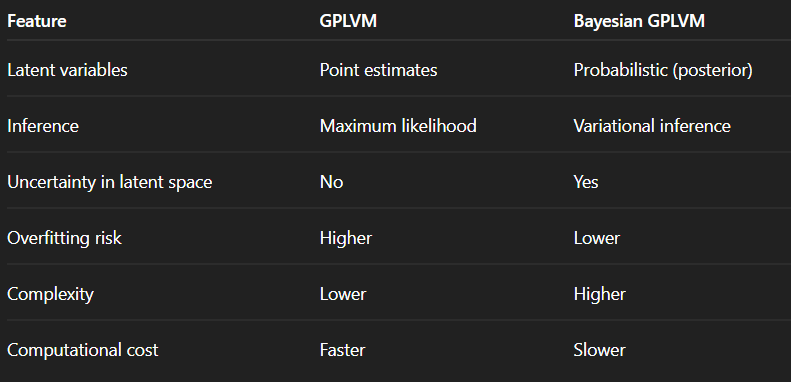